# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Bidirectional, SimpleRNN
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import StandardScaler

2024-05-22 14:06:08.866287: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-22 14:06:09.242363: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-22 14:06:09.242554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-22 14:06:09.290544: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-22 14:06:09.435251: I tensorflow/core/platform/cpu_feature_guar

# Load Data

In [2]:
df = pd.read_csv('./Starbucks_stock_history.csv')
df.drop(columns=['Dividends', 'Stock Splits', 'Volume'], inplace=True)
df.head()


,Date,Open,High,Low,Close
0,1992-06-26,0.270957,0.287086,0.264507,0.277409
1,1992-06-29,0.280635,0.303215,0.274183,0.296763
2,1992-06-30,0.303215,0.306440,0.283860,0.287086
3,1992-07-01,0.290312,0.296763,0.280635,0.293538
4,1992-07-02,0.296763,0.296763,0.287086,0.293538


# PreProcess Data

In [3]:
n=len(df)
step = 5 # Average Working Days a week
train_start = 21 * 12 * 22
train_end = train_start + (21 * 12 * 2) # 5 years
val_end = train_end + 21 * 12 * 2

learning_rate = 0.001
epochs = 1000

In [4]:
print(df['Date'][train_start])
print(df['Date'][train_end])
print(df['Date'][val_end])
print(df['Date'][n-1])

2014-07-01
2016-06-30
2018-07-02
2021-10-01


In [5]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])

    return np.array(data), np.array(labels)

In [6]:
multi_data = df.drop(columns=['Date'], axis=1).values

## Splitting Data Using Multivariative Function

In [7]:
TRAIN_SPLIT = train_end
VAL_SPLIT = val_end
past_history = 21 * 12 * 1 # 1 years back
future_target = 21 # 1 Month ahead

STEP = step

x_train_single, y_train_single = multivariate_data(multi_data, multi_data[:, 1], 0, TRAIN_SPLIT,
                                                   past_history,
                                                   future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_data(multi_data, multi_data[:, 1],
                                               TRAIN_SPLIT, VAL_SPLIT, past_history,
                                               future_target, STEP,
                                               single_step=True)
x_test_single, y_test_single = multivariate_data(multi_data, multi_data[:, 1],
                                               VAL_SPLIT, None, past_history,
                                               future_target, STEP,
                                               single_step=True)

In [8]:
print(x_train_single.shape)
print ('Single window of past history : {}'.format(x_train_single[0].shape))
print(x_train_single.shape[-2:])

(5796, 51, 4)
Single window of past history : (51, 4)
(51, 4)


## Scaling Data using Standart Scaler

In [9]:
scaler = StandardScaler()

x_train_single_scaled = scaler.fit_transform(x_train_single.reshape(-1, x_train_single.shape[-1])).reshape(x_train_single.shape)
x_test_single_scaled = scaler.transform(x_test_single.reshape(-1, x_test_single.shape[-1])).reshape(x_test_single.shape)
x_val_single_scaled = scaler.transform(x_val_single.reshape(-1, x_val_single.shape[-1])).reshape(x_val_single.shape)

In [10]:
y_scaler = StandardScaler()
y_train_single_scaled = y_scaler.fit_transform(y_train_single.reshape(-1, 1)).reshape(y_train_single.shape)
y_test_single_scaled = y_scaler.transform(y_test_single.reshape(-1, 1)).reshape(y_test_single.shape)
y_val_single_scaled = y_scaler.transform(y_val_single.reshape(-1, 1)).reshape(y_val_single.shape)

## Convert Data to Tensor

In [11]:
BUFFER_SIZE = 10000
BATCH_SIZE = 16
EVALUATION_INTERVAL = 200

train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single_scaled, y_train_single_scaled))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single_scaled, y_val_single_scaled))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

test_data_single = tf.data.Dataset.from_tensor_slices((x_test_single_scaled, y_test_single_scaled))
test_data_single = test_data_single.batch(BATCH_SIZE).repeat()

2024-05-22 14:06:18.381519: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-22 14:06:19.230586: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-22 14:06:19.230722: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-22 14:06:19.246896: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-22 14:06:19.246979: I external/local_xla/xla/stream_executor

# Modelling

## Model 1

### Creating Model

In [12]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=20, return_sequences=True)(i)
    x = Dropout(0.2)(x)
    x = LSTM(units=20)(x)
    x = Dropout(0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(1)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [13]:
Model1 = create_model(x_train_single.shape[1], x_train_single.shape[2])

### Model Summary

In [14]:
Model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 51, 4)]           0         
                                                                 
 lstm (LSTM)                 (None, 51, 20)            2000      
                                                                 
 dropout (Dropout)           (None, 51, 20)            0         
                                                                 
 lstm_1 (LSTM)               (None, 20)                3280      
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 batch_normalization (Batch  (None, 20)                80        
 Normalization)                                                  
                                                             

### Model Compilation

In [15]:
Model1.compile(optimizer=RMSprop(learning_rate=learning_rate), loss=MeanAbsoluteError(), metrics=['mae'])

### Model training

In [16]:
checkpointer = ModelCheckpoint(filepath = 'weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
his_model1=Model1.fit(train_data_single, 
               steps_per_epoch=EVALUATION_INTERVAL, 
               epochs=100, 
               validation_data=val_data_single, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping],
               validation_steps=50)

Epoch 1/100


2024-05-22 14:06:30.738462: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-05-22 14:06:33.557404: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f9ccd092f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-22 14:06:33.557484: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-05-22 14:06:33.598065: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1716361593.847054   22921 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 [==============================] - ETA: 0s - loss: 0.3950 - mae: 0.3950
Epoch 1: val_loss improved from inf to 2.65175, saving model to weights_best.hdf5


/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


200/200 [==============================] - 22s 51ms/step - loss: 0.3950 - mae: 0.3950 - val_loss: 2.6518 - val_mae: 2.6518
Epoch 2/100
200/200 [==============================] - ETA: 0s - loss: 0.3159 - mae: 0.3159
Epoch 2: val_loss improved from 2.65175 to 1.79671, saving model to weights_best.hdf5
200/200 [==============================] - 8s 38ms/step - loss: 0.3159 - mae: 0.3159 - val_loss: 1.7967 - val_mae: 1.7967
Epoch 3/100
200/200 [==============================] - ETA: 0s - loss: 0.2768 - mae: 0.2768
Epoch 3: val_loss improved from 1.79671 to 1.16286, saving model to weights_best.hdf5
200/200 [==============================] - 8s 42ms/step - loss: 0.2768 - mae: 0.2768 - val_loss: 1.1629 - val_mae: 1.1629
Epoch 4/100
200/200 [==============================] - ETA: 0s - loss: 0.2390 - mae: 0.2390
Epoch 4: val_loss improved from 1.16286 to 0.17776, saving model to weights_best.hdf5
200/200 [==============================] - 9s 43ms/step - loss: 0.2390 - mae: 0.2390 - val_loss: 0.

### Loading Best Weight

In [17]:
Model1.load_weights('weights_best.hdf5')

### Model Prediction & Evaluation

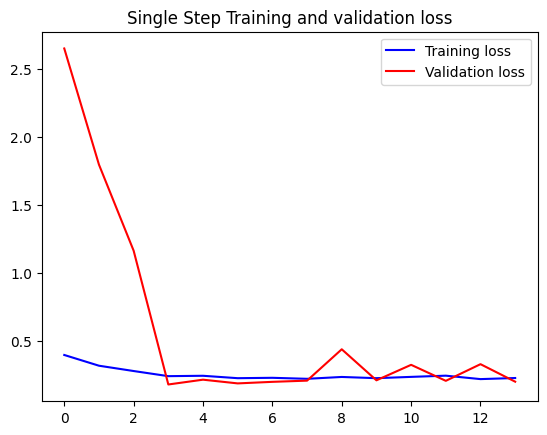

In [18]:
def plot_train_history(history, title):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()
    
plot_train_history(his_model1, 'Single Step Training and validation loss')

From this graph we can see that the model has reached convergence, in 3 epoch, with it having best val mean absolute error of 0.17776

In [19]:
pred = y_scaler.inverse_transform(Model1.predict(x_test_single_scaled))

18/18 [==============================] - 1s 17ms/step


In [20]:
def create_time_steps(length):
    return list(range(-length, 0))

def show_plot(plot_data, delta, title):
    labels = ['History', 'True Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps = create_time_steps(plot_data[0].shape[0])
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, x in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10,
                   label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
        plt.legend()
        plt.xlim([time_steps[0], (future+5)*2])
        plt.xlabel('Time-Step')
    
    return plt

#### Model Inference

1/1 [==============================] - 1s 1s/step


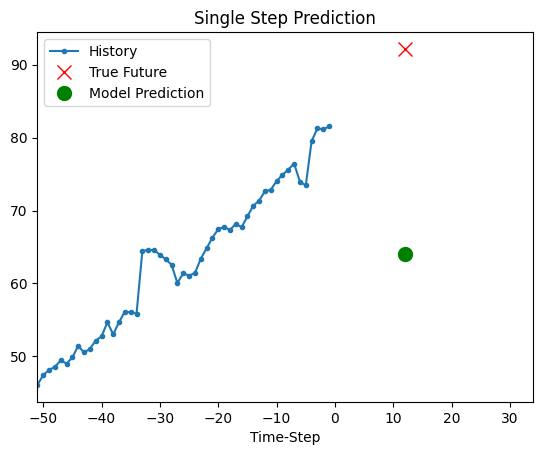

1/1 [==============================] - 0s 53ms/step


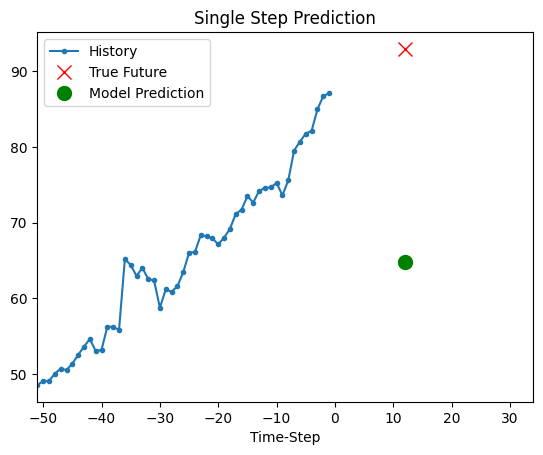

1/1 [==============================] - 0s 47ms/step


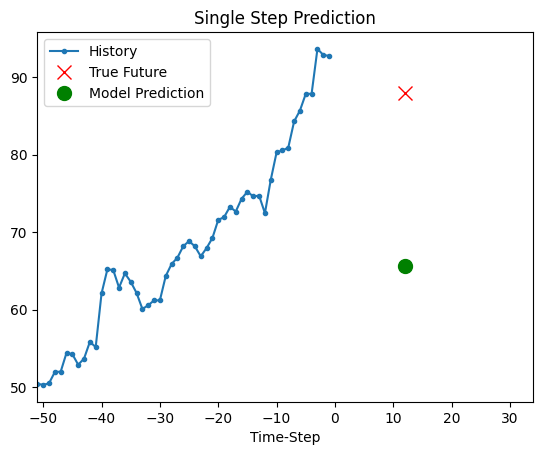

1/1 [==============================] - 0s 33ms/step


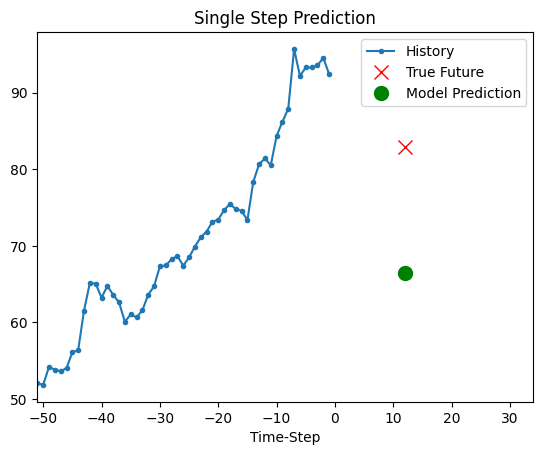

1/1 [==============================] - 0s 48ms/step


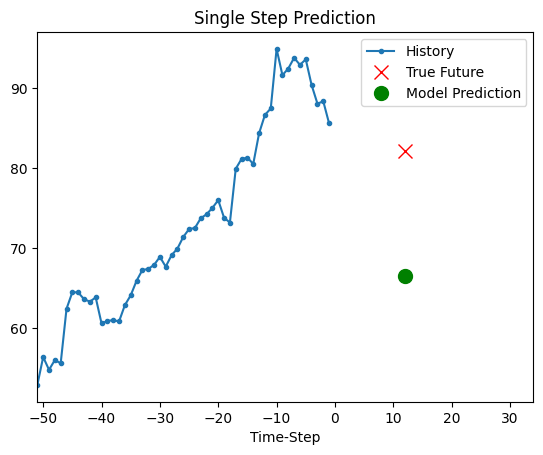

In [21]:
for x, y in test_data_single.take(5):
    # Inverse Scaling
    pred = y_scaler.inverse_transform(Model1.predict(x))
    x = scaler.inverse_transform(x.numpy().reshape(-1, x.shape[-1])).reshape(x.shape)
    y = y_scaler.inverse_transform(y.numpy().reshape(-1, 1)).reshape(y.shape)
    
    show_plot([x[0][:, 1], y[0], pred[0]], 12, 'Single Step Prediction').show()

With a scaled mean absolute error of 0.17776. And the inablity of the model to predict the target variable is can also be seen on the inference of the model, with the predicted value and the true value having such a large difference (visually about $20 difference). With the model seemingly not overfitting, we can conclude that the model is not complex enough to capture the pattern of the data.

## Model 2 (Bidirectional RNN)

### Creating Model

In [22]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=20, return_sequences=True)(i)
    x = Dropout(0.2)(x)
    x = Bidirectional(SimpleRNN(units=20))(x)
    x = Dropout(0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(1)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [23]:
Model2 = create_model(x_train_single.shape[1], x_train_single.shape[2])

In [24]:
Model2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 51, 4)]           0         
                                                                 
 lstm_2 (LSTM)               (None, 51, 20)            2000      
                                                                 
 dropout_2 (Dropout)         (None, 51, 20)            0         
                                                                 
 bidirectional (Bidirection  (None, 40)                1640      
 al)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 40)                0         
                                                                 
 batch_normalization_1 (Bat  (None, 40)                160       
 chNormalization)                                          

### Model Compilation

In [25]:
Model2.compile(optimizer=RMSprop(learning_rate=learning_rate), loss=MeanAbsoluteError(), metrics=['mae'])

### Model Training

In [26]:
checkpointer = ModelCheckpoint(filepath = 'weights_best_bidirectional.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
his_model2=Model2.fit(train_data_single, 
               steps_per_epoch=EVALUATION_INTERVAL, 
               epochs=100, 
               validation_data=val_data_single, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping],
               validation_steps=50)

Epoch 1/100
200/200 [==============================] - ETA: 0s - loss: 0.5646 - mae: 0.5646
Epoch 1: val_loss improved from inf to 0.44387, saving model to weights_best_bidirectional.hdf5
200/200 [==============================] - 120s 571ms/step - loss: 0.5646 - mae: 0.5646 - val_loss: 0.4439 - val_mae: 0.4439


/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/100
200/200 [==============================] - ETA: 0s - loss: 0.3933 - mae: 0.3933
Epoch 2: val_loss improved from 0.44387 to 0.34881, saving model to weights_best_bidirectional.hdf5
200/200 [==============================] - 93s 464ms/step - loss: 0.3933 - mae: 0.3933 - val_loss: 0.3488 - val_mae: 0.3488
Epoch 3/100
200/200 [==============================] - ETA: 0s - loss: 0.3436 - mae: 0.3436
Epoch 3: val_loss improved from 0.34881 to 0.16442, saving model to weights_best_bidirectional.hdf5
200/200 [==============================] - 98s 489ms/step - loss: 0.3436 - mae: 0.3436 - val_loss: 0.1644 - val_mae: 0.1644
Epoch 4/100
200/200 [==============================] - ETA: 0s - loss: 0.2901 - mae: 0.2901
Epoch 4: val_loss did not improve from 0.16442
200/200 [==============================] - 95s 475ms/step - loss: 0.2901 - mae: 0.2901 - val_loss: 0.1663 - val_mae: 0.1663
Epoch 5/100
200/200 [==============================] - ETA: 0s - loss: 0.2512 - mae: 0.2512
Epoch 5: val_

### Model Evaluation

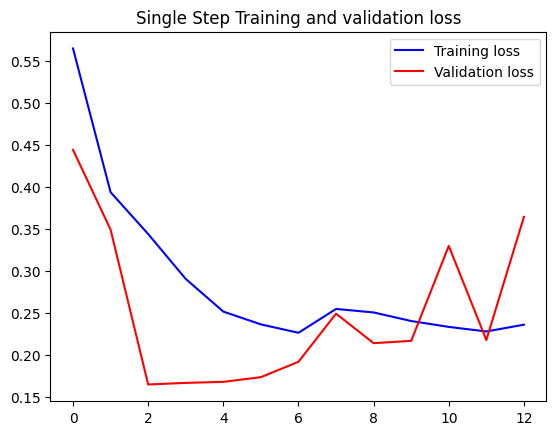

In [27]:
plot_train_history(his_model2, 'Single Step Training and validation loss')

From the graph we can see that the model is generally reaching for convergence, withe the vall loss for epoch 2 - 5 being the lowest. The model has a best val mean absolute error of 0.16442

In [28]:
Model2.load_weights('weights_best_bidirectional.hdf5')

1/1 [==============================] - 1s 824ms/step


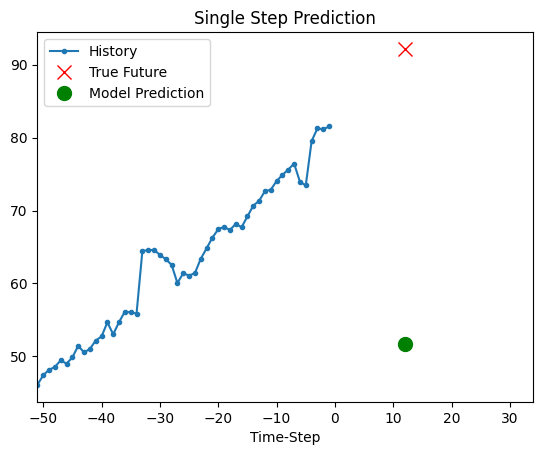

1/1 [==============================] - 0s 38ms/step


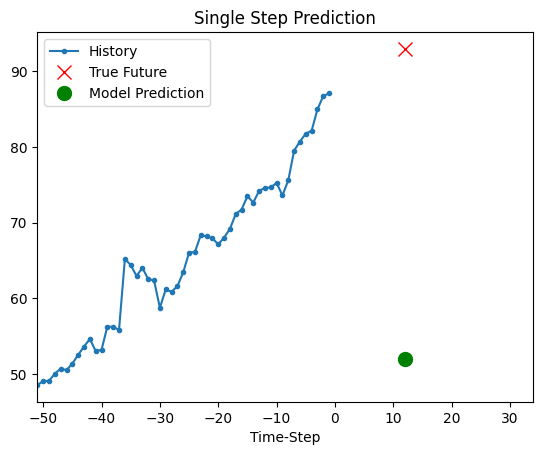

1/1 [==============================] - 0s 65ms/step


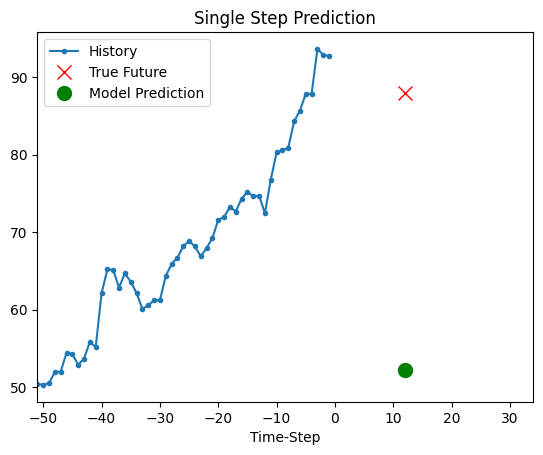

1/1 [==============================] - 0s 36ms/step


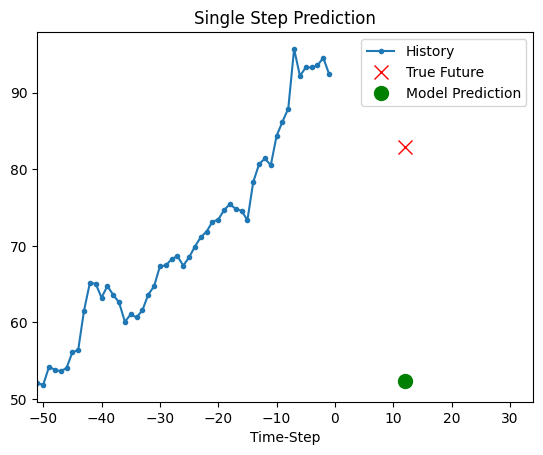

1/1 [==============================] - 0s 35ms/step


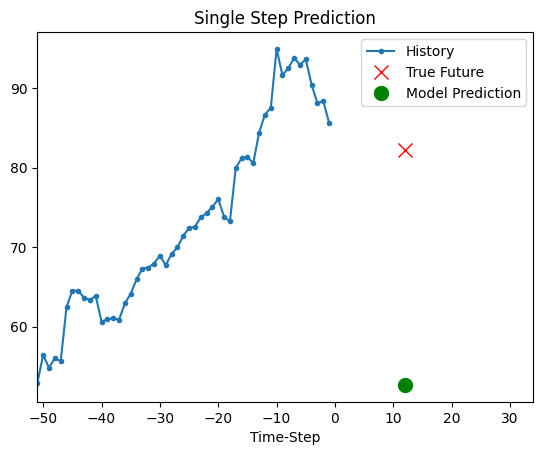

In [29]:
for x, y in test_data_single.take(5):
    # Inverse Scaling
    pred = y_scaler.inverse_transform(Model2.predict(x))
    x = scaler.inverse_transform(x.numpy().reshape(-1, x.shape[-1])).reshape(x.shape)
    y = y_scaler.inverse_transform(y.numpy().reshape(-1, 1)).reshape(y.shape)
    
    show_plot([x[0][:, 1], y[0], pred[0]], 12, 'Single Step Prediction').show()

With a scaled mean absolute error of 0.16442, The inablity of the model to predict the target variable is can also be seen on the inference of the model, with the predicted value and the true value having such a large difference (visually about $20-$30 difference). The inabilities of the model to predict the target variable can be caused by the model being overfitting, and the model being too simple to predict the target variable. 

This conclude that the bidirectional model is performing better in hte train and validation data, but when exposed to a new kind unseen data (test), the model is **performing considerably worse** than the previous model. This is accentuated by the fact that the model **took longer to train per epochs**.

# Image Segmentation VS Object Detection

Image segmentation differs from object detection in that it is a pixel-level task. In image segmentation, the goal is to classify each pixel in the image. Object detection, on the other hand, is a bounding box task. The goal is to detect the presence of objects in an image and locate them with a bounding box.

# JOKE : 